# ML Introduction
It is a branch of Ai that allow computers to learn from data or patterns and make different types of  predictions.
In easy language ML means teaching to a computer using data so that it can predict pattern on new or unseen data.
1. AI->ML->DL
1.  We have three types of Machine Learning:
1. Supervised Machine Learning : The data contains both input and know output.
2. We have two subtypes of supervised ML :
3.  1. regression: Used for numerical data prediction.
4.   2. Classification: used for categorical prediction.
5. Unsupervised Machine Learning: The data has no target/ output column.  
6. -Different types of algorithm which we can use here
7.  1. K-Means Clustering
8.  2. DBSCAN (Density Based clustering algorithm)
9.   3. PCA  
10.  Reinforcement ML: The data is going to learn from action, reward or errors and penalties
11.  Steps of ML
12.  1. Collection of data
13.  2. Feature (Input variable/column) 
14.  3. Target (output variable which we have to predict)
15.  4. Training (Teaching the model through data) 
16.  5. Testing(Testing the model on unseen data)
17.  6. Prediction (models output for new data)
18.  7. Algorithm(model used to learn pattern)
19.  8. Accuracy (How many prediction are correct)
20.  9. Overfitting(model memorize training data too much)
21.  10. Underfitting (Model fails to learn important pattern)  
22.  data 
23.  -> numerical -> continuous and descrete
24.  -> categorical -> nominal and ordinal
25.  nominal : no order 
26.  eg.name -> john,alice
27.  ordinal: which follows some order
28.  Eg. good,better,best
29.  

In [1]:
# EDA
import pandas as pd
import numpy as np
import sklearn
from scipy.stats import skew

installing joblib in terminal 
 python -m pip install --upgrade pip

In [2]:
df=pd.read_csv("Automobile_data-selected-columns.csv")

In [3]:
df

,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base
0,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6
1,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6
2,1,?,alfa-romero,gas,std,two,hatchback,rwd,front,94.5
3,2,164,audi,gas,std,four,sedan,fwd,front,99.8
4,2,164,audi,gas,std,four,sedan,4wd,front,99.4
...,...,...,...,...,...,...,...,...,...,...
200,-1,95,volvo,gas,std,four,sedan,rwd,front,109.1
201,-1,95,volvo,gas,turbo,four,sedan,rwd,front,109.1
202,-1,95,volvo,gas,std,four,sedan,rwd,front,109.1
203,-1,95,volvo,diesel,turbo,four,sedan,rwd,front,109.1


In [4]:
df.head()

,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base
0,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6
1,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6
2,1,?,alfa-romero,gas,std,two,hatchback,rwd,front,94.5
3,2,164,audi,gas,std,four,sedan,fwd,front,99.8
4,2,164,audi,gas,std,four,sedan,4wd,front,99.4


In [5]:
df.tail()

,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base
200,-1,95,volvo,gas,std,four,sedan,rwd,front,109.1
201,-1,95,volvo,gas,turbo,four,sedan,rwd,front,109.1
202,-1,95,volvo,gas,std,four,sedan,rwd,front,109.1
203,-1,95,volvo,diesel,turbo,four,sedan,rwd,front,109.1
204,-1,95,volvo,gas,turbo,four,sedan,rwd,front,109.1


In [6]:
df.shape

(205, 10)

In [7]:
df.columns

Index(['symboling', 'normalized-losses', 'make', 'fuel-type', 'aspiration',
       'num-of-doors', 'body-style', 'drive-wheels', 'engine-location',
       'wheel-base'],
      dtype='str')

In [8]:
df.nunique() #no.of unique values

symboling             6
normalized-losses    52
make                 22
fuel-type             2
aspiration            2
num-of-doors          3
body-style            5
drive-wheels          3
engine-location       2
wheel-base           53
dtype: int64

In [9]:
df['symboling'].unique()

array([ 3,  1,  2,  0, -1, -2])

In [10]:
df['normalized-losses'].unique()


<StringArray>
[  '?', '164', '158', '192', '188', '121',  '98',  '81', '118', '148', '110',
 '145', '137', '101',  '78', '106',  '85', '107', '104', '113', '150', '129',
 '115',  '93', '142', '161', '153', '125', '128', '122', '103', '168', '108',
 '194', '231', '119', '154',  '74', '186',  '83', '102',  '89',  '87',  '77',
  '91', '134',  '65', '197',  '90',  '94', '256',  '95']
Length: 52, dtype: str

In [11]:
df.isnull().sum()

symboling            0
normalized-losses    0
make                 0
fuel-type            0
aspiration           0
num-of-doors         0
body-style           0
drive-wheels         0
engine-location      0
wheel-base           0
dtype: int64

In [12]:
for i in df['normalized-losses']:
    if not(i.isdigit()):
        print(i,end=',')

?,?,?,?,?,?,?,?,?,?,?,?,?,?,?,?,?,?,?,?,?,?,?,?,?,?,?,?,?,?,?,?,?,?,?,?,?,?,?,?,?,

In [13]:
# replace ? with null value
#df['normalized-losses'].replace('?',np.nan,inplace=True) # convert values to null numpy function
df['normalized-losses']=df['normalized-losses'].replace('?',np.nan)

In [14]:
df.isnull().sum()

symboling             0
normalized-losses    41
make                  0
fuel-type             0
aspiration            0
num-of-doors          0
body-style            0
drive-wheels          0
engine-location       0
wheel-base            0
dtype: int64

In [15]:
df['normalized-losses'].dtype

<StringDtype(storage='python', na_value=nan)>

In [16]:
#convert to float
df['normalized-losses']=df['normalized-losses'].astype("float64")

In [17]:
df['normalized-losses'].dtype

dtype('float64')

In [18]:
# find mean of normalised-losses
mean=df['normalized-losses'].mean()

In [19]:
# replace all nan of normalised losses with mean
df['normalized-losses']=df['normalized-losses'].fillna(mean)

In [20]:
df.isnull().sum()

symboling            0
normalized-losses    0
make                 0
fuel-type            0
aspiration           0
num-of-doors         0
body-style           0
drive-wheels         0
engine-location      0
wheel-base           0
dtype: int64

In [21]:
# outliers
import seaborn as sns

<Axes: xlabel='wheel-base'>

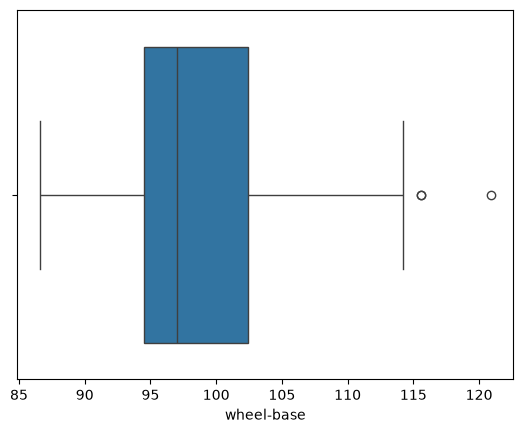

In [22]:
sns.boxplot(data=df,x=df['wheel-base'])

In [23]:
q1=np.percentile(df['wheel-base'],25)
q1

np.float64(94.5)

In [24]:
q2=np.percentile(df['wheel-base'],50)
q3=np.percentile(df['wheel-base'],75)
q2

np.float64(97.0)

In [25]:
q3

np.float64(102.4)

In [26]:
iqr=q3-q1
iqr

np.float64(7.900000000000006)

In [27]:
uw=q3+1.5*iqr
uw

np.float64(114.25000000000001)

In [28]:
lw=q1-1.5*iqr
lw

np.float64(82.64999999999999)

<Axes: xlabel='wheel-base', ylabel='make'>

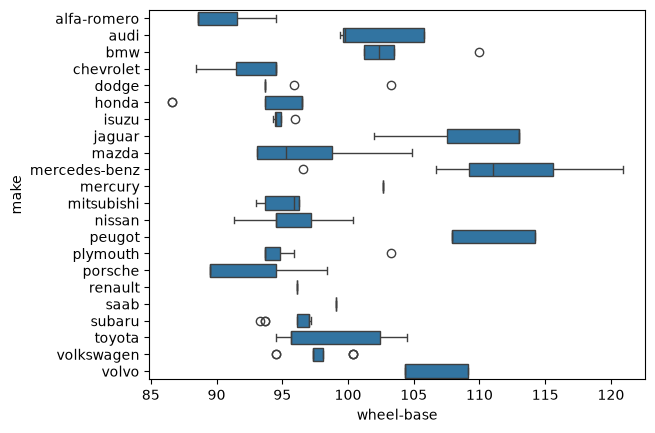

In [29]:
#remove outliers
sns.boxplot(data=df,x=df['wheel-base'],y="make")

In [30]:
df[(df['make']=="bmw")&(df['wheel-base']>105)]

,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base
17,0,122.0,bmw,gas,std,four,sedan,rwd,front,110.0


In [31]:
df.drop(17,inplace=True)

In [32]:
for make in df['make'].unique():  # 
    wheel_base=df[df['make']==make]['wheel-base']
    print(make,wheel_base)

alfa-romero 0    88.6
1    88.6
2    94.5
Name: wheel-base, dtype: float64
audi 3     99.8
4     99.4
5     99.8
6    105.8
7    105.8
8    105.8
9     99.5
Name: wheel-base, dtype: float64
bmw 10    101.2
11    101.2
12    101.2
13    101.2
14    103.5
15    103.5
16    103.5
Name: wheel-base, dtype: float64
chevrolet 18    88.4
19    94.5
20    94.5
Name: wheel-base, dtype: float64
dodge 21     93.7
22     93.7
23     93.7
24     93.7
25     93.7
26     93.7
27     93.7
28    103.3
29     95.9
Name: wheel-base, dtype: float64
honda 30    86.6
31    86.6
32    93.7
33    93.7
34    93.7
35    96.5
36    96.5
37    96.5
38    96.5
39    96.5
40    96.5
41    96.5
42    96.5
Name: wheel-base, dtype: float64
isuzu 43    94.3
44    94.5
45    94.5
46    96.0
Name: wheel-base, dtype: float64
jaguar 47    113.0
48    113.0
49    102.0
Name: wheel-base, dtype: float64
mazda 50     93.1
51     93.1
52     93.1
53     93.1
54     93.1
55     95.3
56     95.3
57     95.3
58     95.3
59     98.8

In [33]:
q1=np.percentile(wheel_base,25)
q1

np.float64(104.3)

In [34]:
q2=np.percentile(wheel_base,50)
q3=np.percentile(wheel_base,75)


In [35]:
q2

np.float64(104.3)

In [36]:
q3

np.float64(109.1)

In [37]:
iqr=q3-q1
iqr

np.float64(4.799999999999997)

In [38]:
uw=q3+1.5*iqr
uw

np.float64(116.29999999999998)

In [39]:
index=wheel_base[wheel_base>uw].index
print(index)

Index([], dtype='int64')


In [40]:
for make in df['make'].unique():  # 
    wheel_base=df[df['make']==make]['wheel-base']
    #print(make,wheel_base)
    q1=np.percentile(wheel_base,25)
    q3=np.percentile(wheel_base,75)
    iqr=q3-q1
    uw=q3+1.5*iqr
    index=wheel_base[wheel_base>uw].index
    #print(make,index)
    if len(index)!=0:
        print(make,index)




dodge Index([28, 29], dtype='int64')
isuzu Index([46], dtype='int64')
plymouth Index([123], dtype='int64')
volkswagen Index([191, 192, 193], dtype='int64')


In [41]:
#now drop index which is greater than upper limit(which is outlier)
for make in df['make'].unique():  # 
    wheel_base=df[df['make']==make]['wheel-base']
    #print(make,wheel_base)
    q1=np.percentile(wheel_base,25)
    q3=np.percentile(wheel_base,75)
    iqr=q3-q1
    uw=q3+1.5*iqr
    index=wheel_base[wheel_base>uw].index
    if len(index)!=0:
        df.drop(index,inplace=True)        



<Axes: xlabel='wheel-base', ylabel='make'>

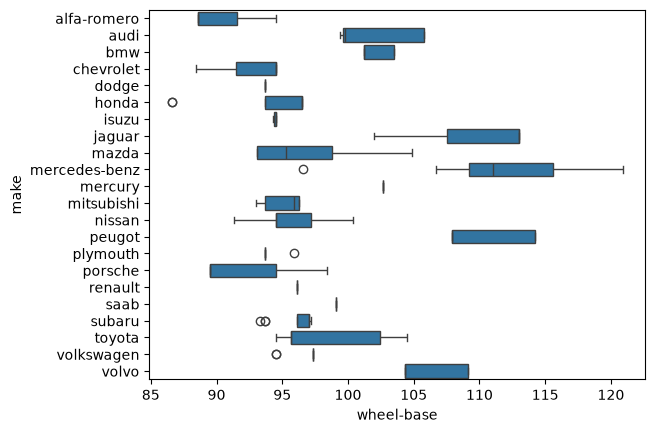

In [42]:
#remove outliers
sns.boxplot(data=df,x=df['wheel-base'],y="make")

In [43]:

for make in df['make'].unique():  # 
    wheel_base=df[df['make']==make]['wheel-base']
    #print(make,wheel_base)
    q1=np.percentile(wheel_base,25)
    q3=np.percentile(wheel_base,75)
    iqr=q3-q1
    lw=q1-1.5*iqr
    index=wheel_base[wheel_base<lw].index
    if len(index)!=0:
        df.drop(index,inplace=True)     



<Axes: xlabel='wheel-base', ylabel='make'>

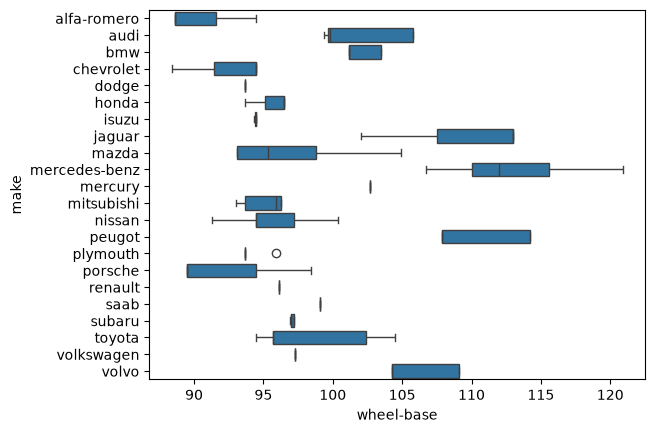

In [44]:
sns.boxplot(x="wheel-base",y="make",data=df)

 # encoding in python = used to convert categorical data into numerical 
 we have two types of encoding
 1. one-hot encoding :
 2.label/ordinal encoding :
 1. label-encoding : is a technique used to convert categorical values 
 2. like "high","med","low" into numerical values(like 0,1,2).
 3. each unique category is assigned an integer value.

In [45]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

In [46]:
num_data=df.select_dtypes(['int64','float64']) # accessing numerical data

In [47]:
num_data

,symboling,normalized-losses,wheel-base
0,3,122.0,88.6
1,3,122.0,88.6
2,1,122.0,94.5
3,2,164.0,99.8
4,2,164.0,99.4
...,...,...,...
200,-1,95.0,109.1
201,-1,95.0,109.1
202,-1,95.0,109.1
203,-1,95.0,109.1


In [48]:
df['normalized-losses']=df['normalized-losses'].astype('float64')


In [49]:
# accessing categorical data
cat_data=df.select_dtypes("object")
cat_data

C:\Users\HP\AppData\Local\Temp\ipykernel_23096\1797144947.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_data=df.select_dtypes("object")


,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location
0,alfa-romero,gas,std,two,convertible,rwd,front
1,alfa-romero,gas,std,two,convertible,rwd,front
2,alfa-romero,gas,std,two,hatchback,rwd,front
3,audi,gas,std,four,sedan,fwd,front
4,audi,gas,std,four,sedan,4wd,front
...,...,...,...,...,...,...,...
200,volvo,gas,std,four,sedan,rwd,front
201,volvo,gas,turbo,four,sedan,rwd,front
202,volvo,gas,std,four,sedan,rwd,front
203,volvo,diesel,turbo,four,sedan,rwd,front


<Axes: xlabel='count', ylabel='make'>

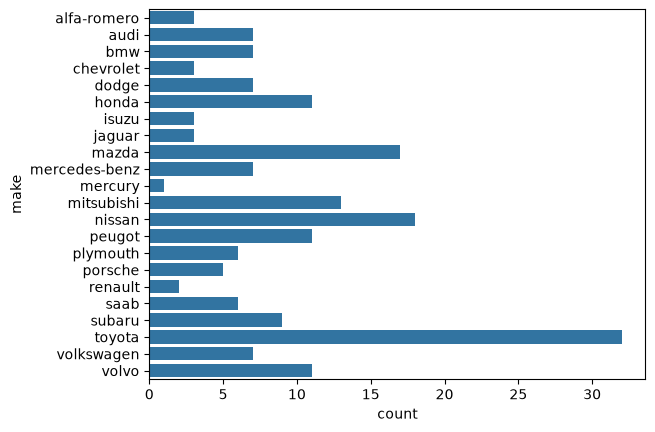

In [50]:
sns.countplot(cat_data['make'])

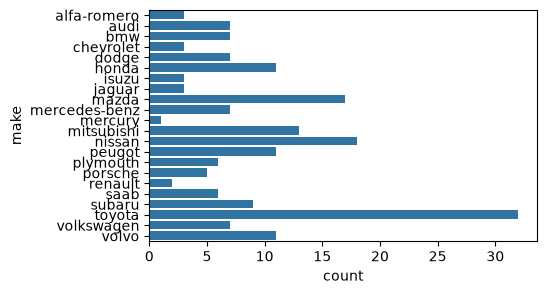

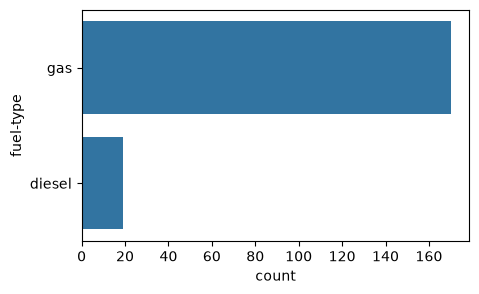

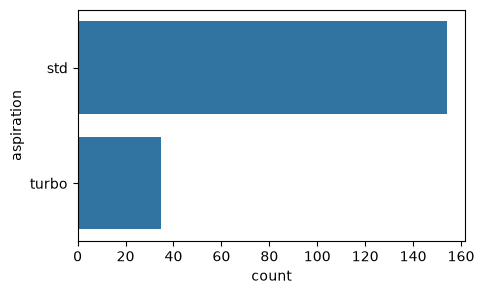

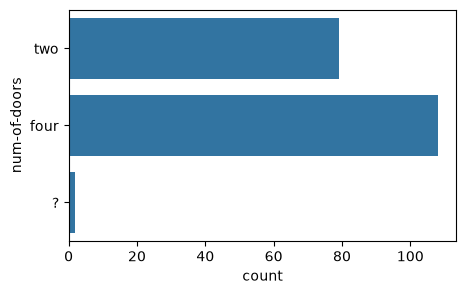

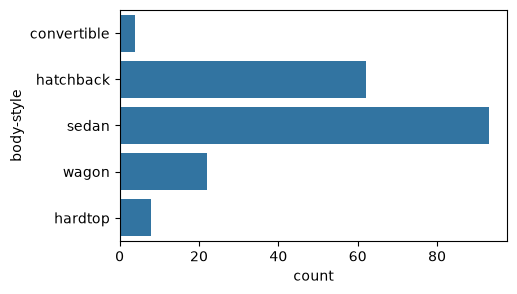

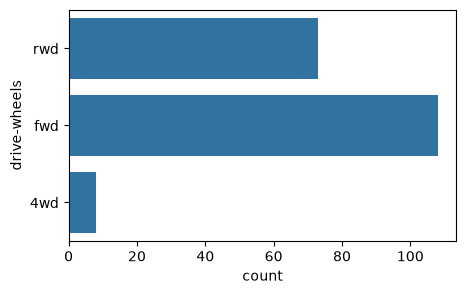

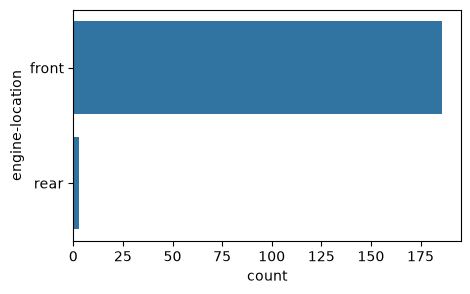

In [51]:
# use for loop and display data in count plot
for i in cat_data:
    plt.figure(figsize=(5,3))
    sns.countplot(cat_data[i])

In [52]:
#one-hot encoding
cat_data['body-style'].head()

0    convertible
1    convertible
2      hatchback
3          sedan
4          sedan
Name: body-style, dtype: str

In [53]:
pd.get_dummies(df['body-style'],dtype=int) # get_dummies is used for one-hot encoding 

,convertible,hardtop,hatchback,sedan,wagon
0,1,0,0,0,0
1,1,0,0,0,0
2,0,0,1,0,0
3,0,0,0,1,0
4,0,0,0,1,0
...,...,...,...,...,...
200,0,0,0,1,0
201,0,0,0,1,0
202,0,0,0,1,0
203,0,0,0,1,0


In [54]:
# Label incoding
from sklearn.preprocessing import LabelEncoder

In [55]:
le=LabelEncoder()

In [56]:
le.fit_transform(df['body-style'])


array([0, 0, 2, 3, 3, 3, 3, 4, 3, 2, 3, 3, 3, 3, 3, 3, 3, 2, 2, 3, 2, 2,
       2, 2, 3, 3, 3, 2, 2, 2, 3, 4, 2, 2, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
       2, 2, 2, 3, 3, 2, 2, 2, 2, 2, 3, 2, 3, 3, 2, 3, 3, 3, 4, 1, 3, 3,
       3, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 3, 3, 3, 3, 3, 3, 3, 3, 4, 3,
       2, 3, 4, 1, 2, 3, 3, 4, 3, 2, 2, 2, 3, 3, 4, 4, 3, 3, 4, 4, 3, 3,
       3, 2, 2, 2, 3, 3, 2, 2, 1, 1, 0, 2, 4, 2, 2, 3, 2, 3, 2, 3, 3, 3,
       3, 3, 3, 4, 4, 4, 4, 2, 2, 2, 4, 4, 4, 3, 2, 3, 2, 3, 2, 3, 3, 2,
       3, 2, 1, 1, 2, 1, 2, 0, 3, 3, 2, 3, 2, 2, 2, 3, 4, 3, 3, 3, 3, 3,
       3, 3, 3, 4, 3, 4, 3, 4, 3, 3, 3, 3, 3])

In [57]:
cat_data['body-style']=le.fit_transform(cat_data['body-style'])

In [58]:
cat_data

,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location
0,alfa-romero,gas,std,two,0,rwd,front
1,alfa-romero,gas,std,two,0,rwd,front
2,alfa-romero,gas,std,two,2,rwd,front
3,audi,gas,std,four,3,fwd,front
4,audi,gas,std,four,3,4wd,front
...,...,...,...,...,...,...,...
200,volvo,gas,std,four,3,rwd,front
201,volvo,gas,turbo,four,3,rwd,front
202,volvo,gas,std,four,3,rwd,front
203,volvo,diesel,turbo,four,3,rwd,front


In [59]:
for col in cat_data:
    le=LabelEncoder()
    cat_data[col]=le.fit_transform(cat_data[col])

In [60]:
cat_data

,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location
0,0,1,0,2,0,2,0
1,0,1,0,2,0,2,0
2,0,1,0,2,2,2,0
3,1,1,0,1,3,1,0
4,1,1,0,1,3,0,0
...,...,...,...,...,...,...,...
200,21,1,0,1,3,2,0
201,21,1,1,1,3,2,0
202,21,1,0,1,3,2,0
203,21,0,1,1,3,2,0


In [61]:
#Numerical data num
# under numerical data we have to take care of skewness and scailing 
# if we have to check skewness of numerical data then here we are going to create distplot
num_data

,symboling,normalized-losses,wheel-base
0,3,122.0,88.6
1,3,122.0,88.6
2,1,122.0,94.5
3,2,164.0,99.8
4,2,164.0,99.4
...,...,...,...
200,-1,95.0,109.1
201,-1,95.0,109.1
202,-1,95.0,109.1
203,-1,95.0,109.1


0.250838232384667
0.6263370866060868
1.1220221196396751


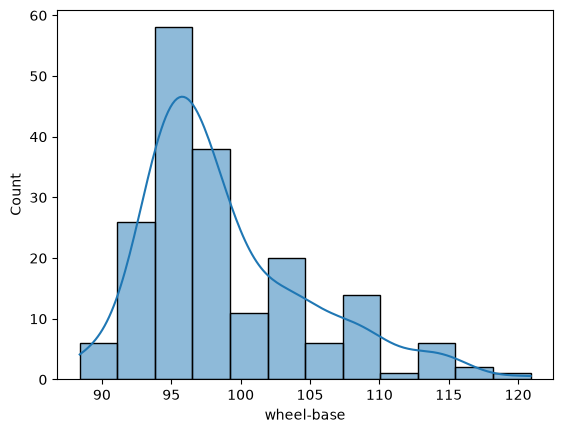

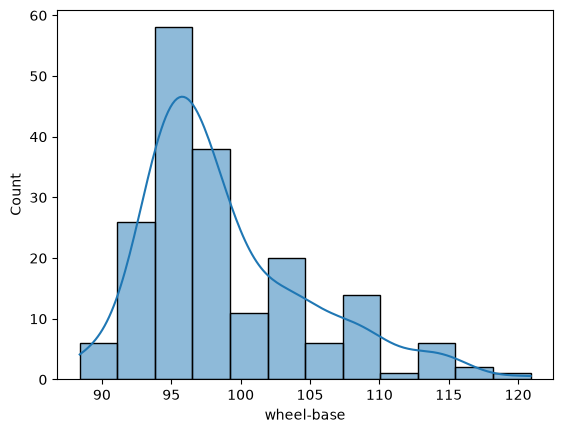

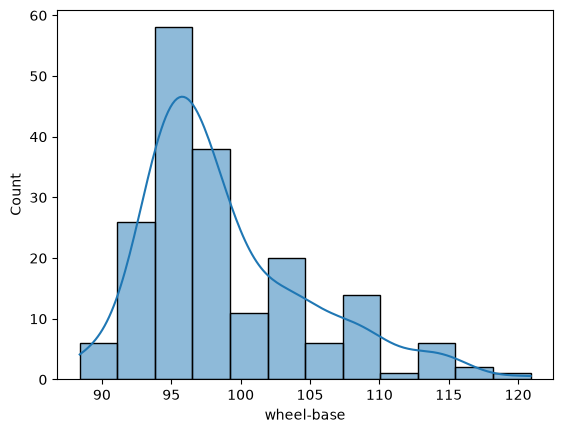

In [62]:
for col in num_data:
    plt.figure()
    sns.histplot(num_data['wheel-base'],kde=True) 
    print(skew(num_data[col]))
# kernel density estimation

#Skewness 
reduce the skewness of wheel_base

In [63]:
# SQRT Function


 two types of scailing we have
 1. min-max scalar
  mm= x-xmin / xmax-xmin
1. 2. standard scaler  
2. 

skewness 1.0592554553268418


C:\Users\HP\AppData\Local\Temp\ipykernel_23096\1369791273.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(np.sqrt(num_data['wheel-base']))


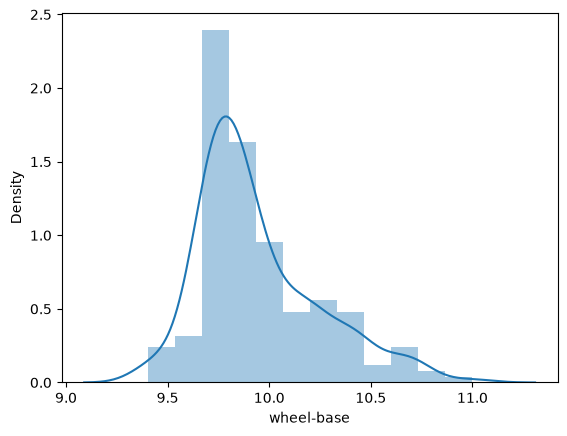

In [64]:
plt.figure()
sns.distplot(np.sqrt(num_data['wheel-base']))
print("skewness",np.sqrt(skew(num_data['wheel-base'])))

C:\Users\HP\AppData\Local\Temp\ipykernel_23096\3794307145.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(np.log(num_data['wheel-base']))


skewness 0.11513252138004064


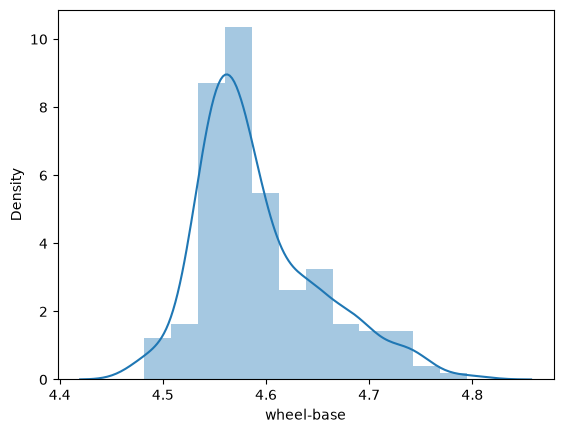

In [65]:
plt.figure()
sns.distplot(np.log(num_data['wheel-base']))
print("skewness",np.log(skew(num_data['wheel-base'])))

In [66]:
# scailing we have two types of scailing 
# 1. min-max scalar
# standard scalar
from sklearn.preprocessing import MinMaxScaler

In [67]:
mm=MinMaxScaler()

In [68]:
mm.fit_transform(num_data[['wheel-base']])  # it represent multi-dimension array

array([[0.00615385],
       [0.00615385],
       [0.18769231],
       [0.35076923],
       [0.33846154],
       [0.35076923],
       [0.53538462],
       [0.53538462],
       [0.53538462],
       [0.34153846],
       [0.39384615],
       [0.39384615],
       [0.39384615],
       [0.39384615],
       [0.46461538],
       [0.46461538],
       [0.46461538],
       [0.        ],
       [0.18769231],
       [0.18769231],
       [0.16307692],
       [0.16307692],
       [0.16307692],
       [0.16307692],
       [0.16307692],
       [0.16307692],
       [0.16307692],
       [0.16307692],
       [0.16307692],
       [0.16307692],
       [0.24923077],
       [0.24923077],
       [0.24923077],
       [0.24923077],
       [0.24923077],
       [0.24923077],
       [0.24923077],
       [0.24923077],
       [0.18153846],
       [0.18769231],
       [0.18769231],
       [0.75692308],
       [0.75692308],
       [0.41846154],
       [0.14461538],
       [0.14461538],
       [0.14461538],
       [0.144

In [69]:
# std_scaler
# standard scaler is the process which we have already learned here the formula of standard scaler is 
# ss=(x-mu)/ std_dev
from sklearn.preprocessing import StandardScaler

In [70]:
ss=StandardScaler()
scaled_data=ss.fit_transform(num_data[['wheel-base']])
scaled_data

array([[-1.72262436],
       [-1.72262436],
       [-0.73780076],
       [ 0.14687128],
       [ 0.08010358],
       [ 0.14687128],
       [ 1.1483868 ],
       [ 1.1483868 ],
       [ 1.1483868 ],
       [ 0.0967955 ],
       [ 0.38055823],
       [ 0.38055823],
       [ 0.38055823],
       [ 0.38055823],
       [ 0.76447252],
       [ 0.76447252],
       [ 0.76447252],
       [-1.75600821],
       [-0.73780076],
       [-0.73780076],
       [-0.87133617],
       [-0.87133617],
       [-0.87133617],
       [-0.87133617],
       [-0.87133617],
       [-0.87133617],
       [-0.87133617],
       [-0.87133617],
       [-0.87133617],
       [-0.87133617],
       [-0.40396226],
       [-0.40396226],
       [-0.40396226],
       [-0.40396226],
       [-0.40396226],
       [-0.40396226],
       [-0.40396226],
       [-0.40396226],
       [-0.77118461],
       [-0.73780076],
       [-0.73780076],
       [ 2.35020542],
       [ 2.35020542],
       [ 0.51409364],
       [-0.97148772],
       [-0